# LangSmith Dataset & Evaluation


## 학습 목표
- LangSmith의 **Dataset**과 **Evaluation** 기능을 이해한다.  
- **자동 평가(Auto Evaluation)** 와 **사용자 정의 평가(Custom Evaluation)** 를 실습한다.  
- 모델의 응답 품질을 **정량적 지표(Metrics)** 로 비교하고 개선 방안을 도출한다.  

| 항목 | 핵심 내용 |
|------|------------|
| Dataset | 평가용 입력·출력 샘플 집합 |
| Evaluator | Run 결과를 점수화하는 평가기 |
| Experiment | Dataset + Chain + Evaluator 조합 |
| 자동 평가 | Built-in evaluator를 통한 질적/정량 평가 |
| 사용자 정의 평가 | Custom evaluator로 도메인별 맞춤 평가 수행 |

## LangSmith 평가(Evaluation)의 개념


### Observability vs Evaluation

| 구분 | Observability | Evaluation |
|------|----------------|-------------|
| 목적 | 실행 로그 추적, 디버깅 | 품질 측정, 성능 개선 |
| 단위 | Run (실행 단위) | Dataset (테스트 세트 단위) |
| 주요 기능 | Trace, Span, Metadata | Scoring, Metrics, Comparison |

> "Evaluation"은 LLM의 **출력 품질을 객관적으로 측정**하기 위한 LangSmith의 기능입니다.

## 1단계: Dataset 생성 실습
- LangSmith에 평가용 Dataset을 업로드하고, 이를 이용해 체인 결과를 평가한다.


### LangSmith 연결

In [1]:
# 1. LangSmith 연결
from langsmith import Client

client = Client()

### 평가용 Dataset 생성

In [2]:
# 2. 평가용 Dataset 생성
dataset = client.create_dataset(
    dataset_name="qa_eval_dataset",
    description="간단한 Q&A 평가용 데이터셋"
)

#### [LangSmith 확인](https://smith.langchain.com/)

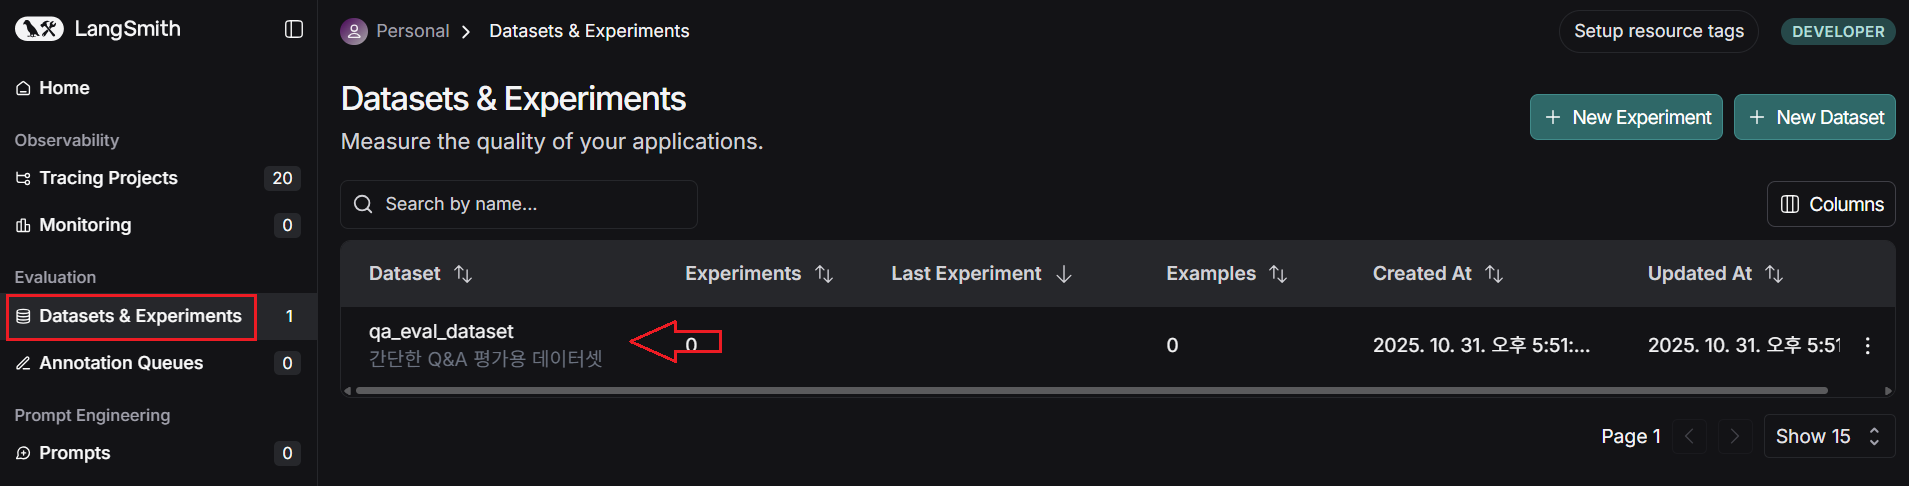

### 샘플 데이터 추가

In [3]:
# 3. 샘플 데이터 추가
examples = [
    {"input": "지구는 태양 주위를 몇 일에 한 바퀴 돕나요?", "output": "약 365일"},
    {"input": "물은 몇 도에서 끓나요?", "output": "100도"},
    {"input": "달은 스스로 빛을 내나요?", "output": "아니요, 태양빛을 반사합니다."}
]

for ex in examples:
    client.create_example(
        inputs={"question": ex["input"]},
        outputs={"answer": ex["output"]},
        dataset_id=dataset.id
    )

print("Dataset 등록 완료:", dataset.name)


Dataset 등록 완료: qa_eval_dataset


#### [LangSmith 확인](https://smith.langchain.com/)

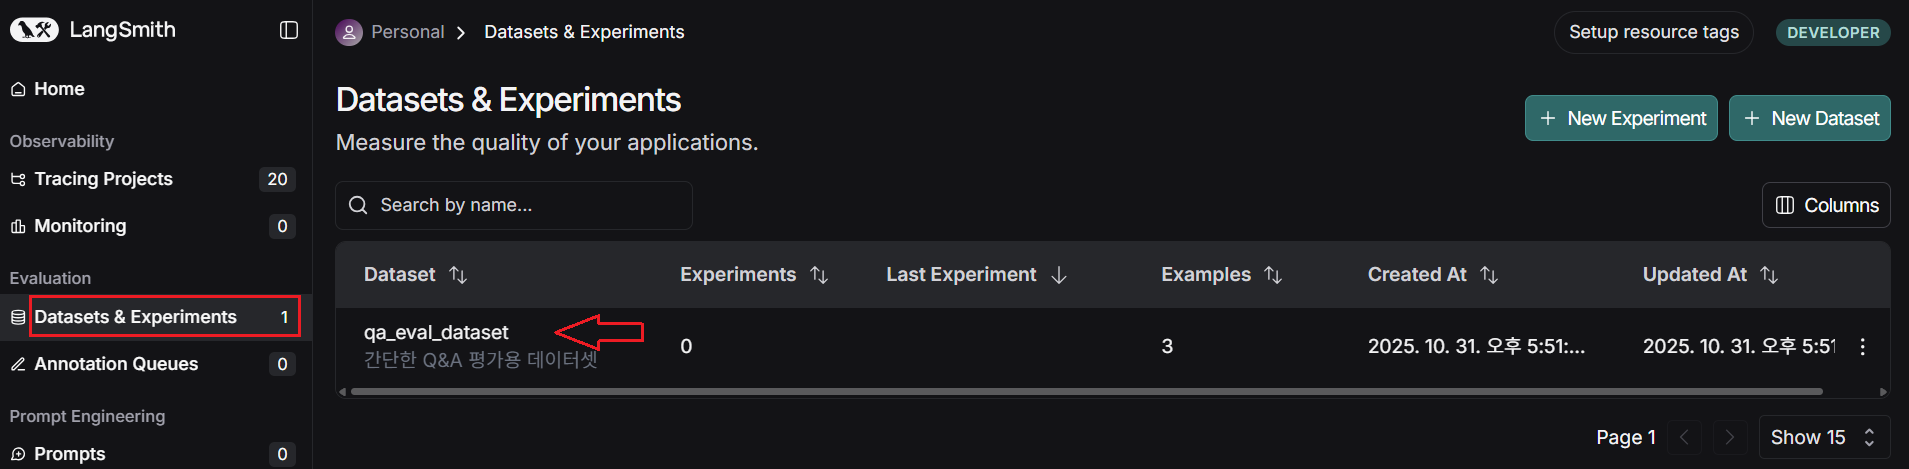

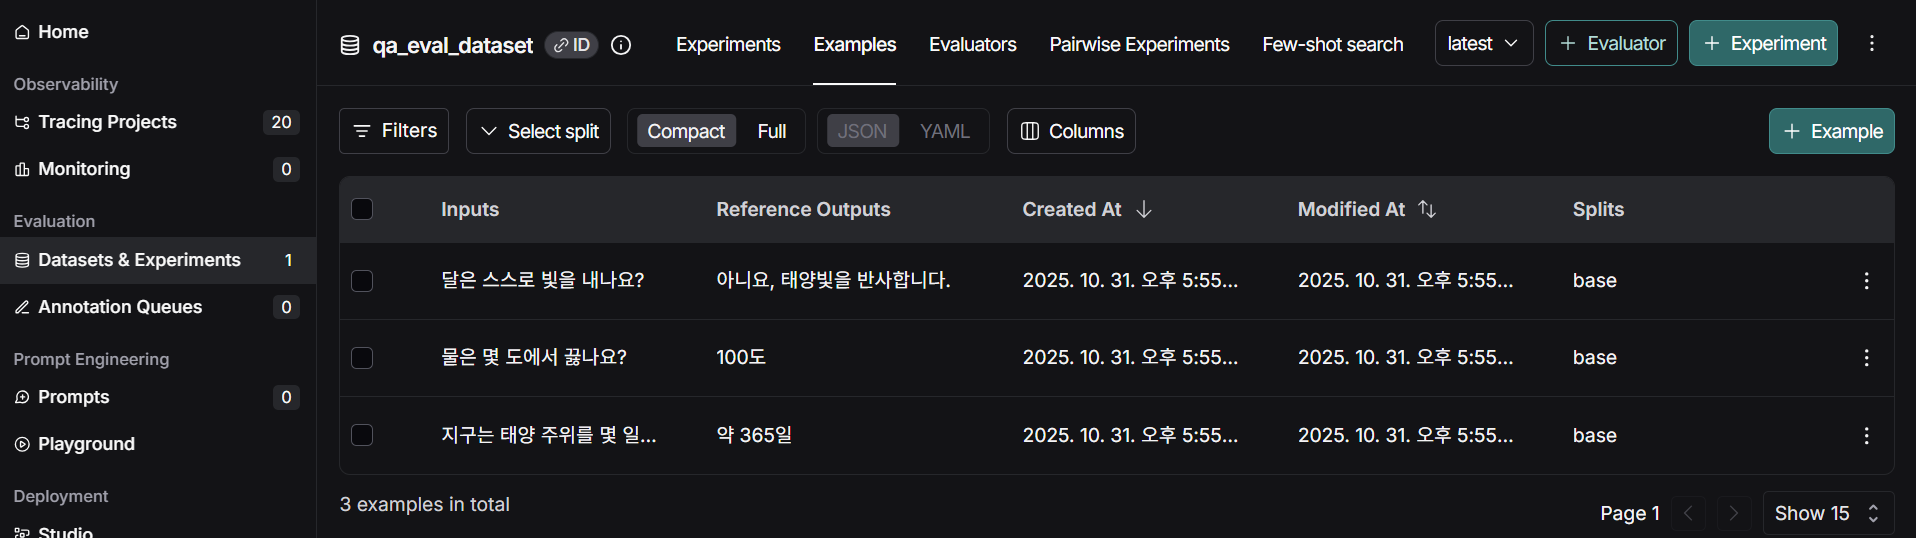

## 2단계: 평가 실행 (Run Evaluation)

### 평가 실행 방법
LangSmith에서 평가를 실행하는 방법은 크게 3가지입니다:
1. **SDK를 사용한 평가** (`client.evaluate()` 또는 `evaluate()`)
2. **UI를 통한 평가** (LangSmith 웹 인터페이스)
3. **REST API를 통한 평가**

이 실습에서는 **SDK를 사용한 평가**를 다룹니다.

### Built-in Evaluators (참고용)
LangSmith는 기본적으로 다음과 같은 **자동 평가기(Evaluator)** 를 제공합니다:
- 이 실습에서는 Custom Evaluator를 직접 작성하는 방법을 학습합니다.


| Evaluator 유형 | 설명 |
|----------------|------|
| **criteria** | LLM을 이용해 질적 평가 (예: "정확한가?", "관련성이 높은가?") |
| **string_distance** | Levenshtein 거리 기반 문자열 유사도 |
| **embedding_distance** | 임베딩 벡터 간 거리 기반 의미 유사도 |
| **exact_match** | 완전 일치 여부 |

### LLM

In [4]:
from dotenv import load_dotenv 

load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq

# 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

### Prompt

In [6]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template("Q: {question}\nA:")

In [7]:
prompt

PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='Q: {question}\nA:')

### Chain

In [11]:
# Chain을 함수 형태로 래핑 (LangSmith evaluate()에서 사용하기 위해)
def qa_chain(inputs: dict) -> dict:
    """질문에 대한 답변을 생성하는 함수"""
    question = inputs.get("question", "")
    result = (prompt | llm).invoke({"question": question})
    # LLM 결과를 문자열로 변환
    answer = result.content if hasattr(result, 'content') else str(result)
    return {"answer": answer}

In [12]:
# 테스트: 함수가 제대로 동작하는지 확인
test_result = qa_chain({"question": "안녕하세요?"})
print(test_result)

{'answer': '안녕하세요! 어떻게 도와드릴까요?'}


### Evaluator 함수 시그니처

**공식 문서 기준 Evaluator 패턴:**
- Evaluator는 3개의 파라미터를 받습니다:
  - `inputs: dict` - 데이터셋의 inputs 필드
  - `outputs: dict` - 모델의 실제 출력
  - `reference_outputs: dict` - 데이터셋의 outputs 필드 (정답)
  
- Evaluator는 다음 중 하나를 반환할 수 있습니다:
  - `bool`: True/False (Pass/Fail)
  - `float`: 0.0~1.0 사이의 점수
  - `dict`: `{"key": "metric_name", "score": 0.5}` 형태


### 평가 실행하기

이제 `client.evaluate()` 함수를 사용하여 평가를 실행합니다.

**주요 파라미터:**
- `target`: 평가할 함수 (입력 dict → 출력 dict 형태)
- `data`: 데이터셋 이름 또는 UUID
- `evaluators`: 평가 함수 리스트
- `experiment_prefix`: 실험 이름 접두사
- `description`: 실험 설명
- `max_concurrency`: 병렬 처리 수 (기본값: 4)

In [16]:
from langsmith import evaluate

# ============================================
# Evaluator 정의 (공식 문서 패턴)
# ============================================
# Evaluator는 inputs, outputs, reference_outputs를 받습니다
# - inputs: 데이터셋의 inputs 필드
# - outputs: 모델의 실제 출력
# - reference_outputs: 데이터셋의 outputs 필드 (정답)

In [17]:
def accuracy_evaluator(inputs: dict, outputs: dict, reference_outputs: dict) -> dict:
    """답변의 정확성을 평가 - 정답의 키워드가 포함되어 있는지 확인"""
    expected = reference_outputs.get("answer", "")
    actual = outputs.get("answer", "")
    
    # 정답의 주요 키워드가 실제 답변에 포함되어 있는지 확인
    keywords = expected.split()
    matches = sum(1 for keyword in keywords if keyword in actual)
    score = matches / len(keywords) if keywords else 0.0
    
    return {"key": "accuracy", "score": score}

In [18]:
def relevance_evaluator(inputs: dict, outputs: dict, reference_outputs: dict) -> dict:
    """답변의 관련성을 평가 - 답변이 질문과 관련있는지 확인"""
    question = inputs.get("question", "")
    actual = outputs.get("answer", "")
    
    # 답변이 비어있지 않고, 최소한의 길이를 가지는지 확인
    has_content = len(actual.strip()) > 5
    score = 1.0 if has_content else 0.0
    
    return {"key": "relevance", "score": score}

In [19]:
def conciseness_evaluator(inputs: dict, outputs: dict, reference_outputs: dict) -> dict:
    """답변의 간결성을 평가 - 답변이 간결한지 확인"""
    actual = outputs.get("answer", "")
    
    # 답변 길이가 적절한지 평가 (100자 이하면 만점, 200자 이상이면 0점)
    length = len(actual)
    if length <= 100:
        score = 1.0
    elif length <= 200:
        score = 0.5
    else:
        score = 0.0
    
    return {"key": "conciseness", "score": score}

In [ ]:
# ============================================
# 평가 실행
# ============================================
client.evaluate(
    qa_chain,  # 평가할 함수
    data="qa_eval_dataset",  # 데이터셋 이름
    evaluators=[accuracy_evaluator, relevance_evaluator, conciseness_evaluator],
    experiment_prefix="qa_eval_run",  # 실험 이름 접두사
    description="Built-in evaluator를 사용한 Q&A 평가",  # 실험 설명
    max_concurrency=2  # 병렬 처리 수
)


View the evaluation results for experiment: 'qa_eval_run-7c8dbb20' at:
https://smith.langchain.com/o/9b0045e0-4ff2-5e75-ab7d-5e8ee81fb8d1/datasets/f52cfe85-e80a-4441-b9b7-ddbaedab7e39/compare?selectedSessions=bf0ce327-7622-4a17-b74d-268fa1e181ed




> 생성된 링크 클릭!!

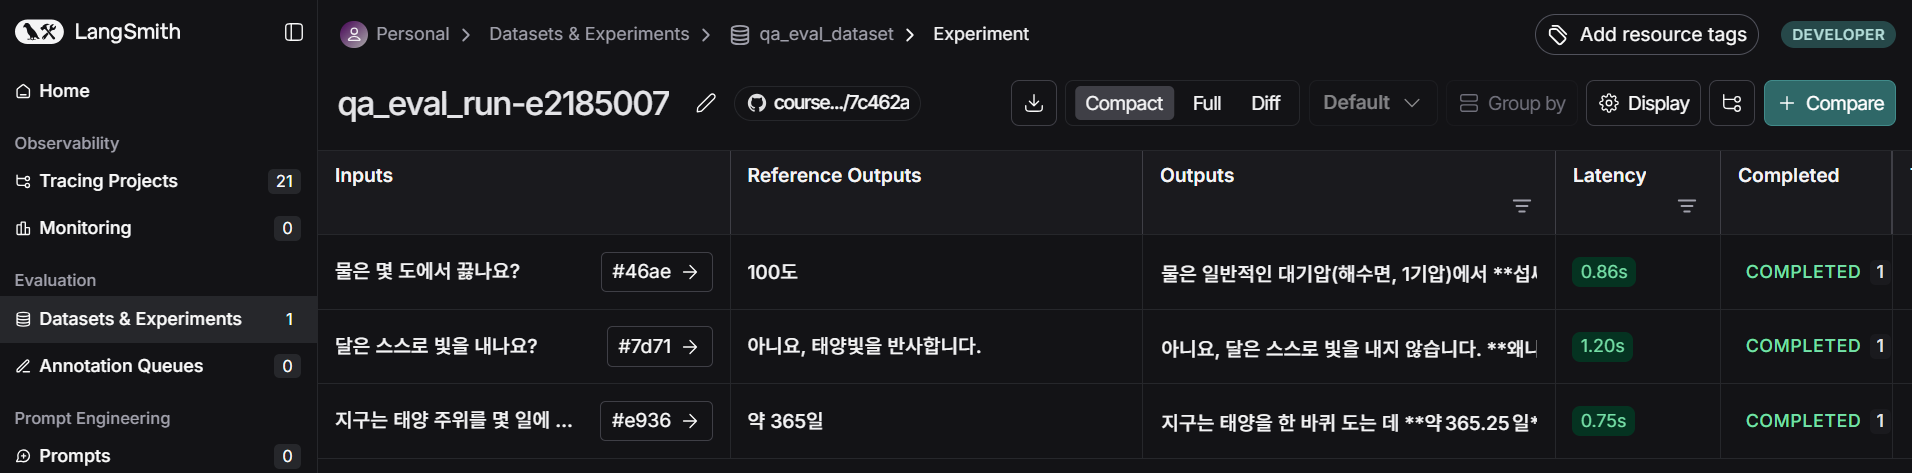

## 3단계: 더 간단한 Custom Evaluator 만들기

### 반환값 타입
Custom Evaluator는 다양한 형태로 결과를 반환할 수 있습니다:
- **`bool`**: 간단한 Pass/Fail 평가
- **`float`**: 0.0~1.0 사이의 점수
- **`dict`**: 더 상세한 메트릭 정보 (`{"key": "metric_name", "score": 0.5}`)

이 섹션에서는 **boolean과 float를 직접 반환**하는 더 간단한 방법을 사용합니다.


In [23]:
# ============================================
# Custom Evaluator 정의 (공식 문서 패턴)
# ============================================
# 더 간단한 방식: boolean이나 숫자를 직접 반환

def keyword_match_evaluator(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """정답의 첫 번째 키워드가 답변에 포함되어 있는지 검사"""
    expected = reference_outputs.get("answer", "")
    actual = outputs.get("answer", "")
    
    # 정답의 첫 단어가 실제 답변에 포함되어 있는지 확인
    first_keyword = expected.split()[0] if expected.split() else ""
    return first_keyword in actual

In [24]:
def length_evaluator(inputs: dict, outputs: dict, reference_outputs: dict) -> float:
    """답변 길이를 0~1 사이의 점수로 반환"""
    actual = outputs.get("answer", "")
    length = len(actual)
    
    # 적정 길이(10~50자)에 대한 점수 계산
    if 10 <= length <= 50:
        return 1.0
    elif length < 10:
        return length / 10.0
    else:
        return max(0.0, 1.0 - (length - 50) / 100.0)

In [ ]:
# ============================================
# Custom Evaluator로 평가 실행
# ============================================
client.evaluate(
    qa_chain,
    data="qa_eval_dataset",
    evaluators=[keyword_match_evaluator, length_evaluator],
    experiment_prefix="qa_custom_eval",
    description="Custom evaluator를 사용한 Q&A 평가",
    max_concurrency=2
)


View the evaluation results for experiment: 'qa_custom_eval-97d58e3c' at:
https://smith.langchain.com/o/9b0045e0-4ff2-5e75-ab7d-5e8ee81fb8d1/datasets/f52cfe85-e80a-4441-b9b7-ddbaedab7e39/compare?selectedSessions=44328ba5-1bbb-4fab-90a2-e3200ffeb341




> 생성된 링크 클릭!!

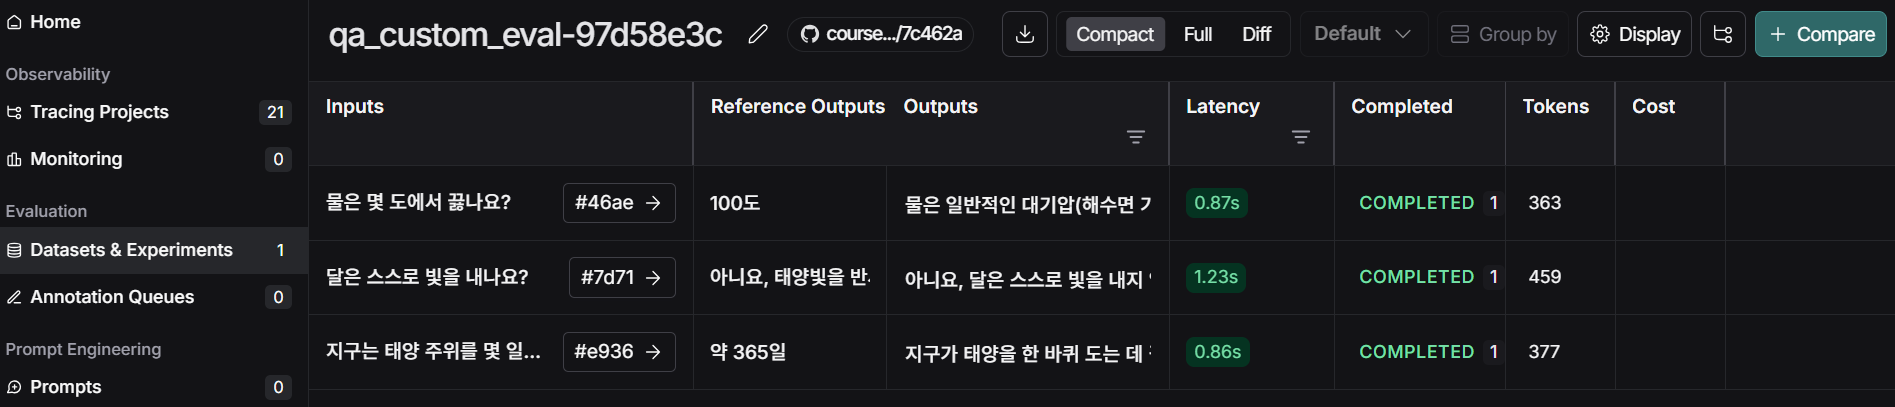